In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
alpha=3
fref=25
Ys,sigs,Y_fs,var_fs,Ys_a,sigs_a,Y_fs_a,var_fs_a,segmentStartTimes,freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                      fref=fref,alpha=alpha)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/4041596471.py:111: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/4041596471.py:112: RuntimeWarning: invalid value encountered in multiply
  S_alpha = FrequencySeries(freqs, S0.data * (freqs/fref)**alpha )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/4041596471.py:127: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data[1:],var_f.data[1:], freqs=freqs[1:], alpha=alpha, fref=fref)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/4041596471.py:129: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys_a[II],sigs_a[II] = calc_Y_sigma_from_Yf_varf(Y_f_a.data[1:],var_f_a.data[1:], freqs=None)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/

stochastic: Done with Interval 1 / 95
	Y       = 8.206688e-04
	Y_a     = 8.206688e-04
	sigma   = 2.646569e-04
	sigma_a = 2.646569e-04
	SNR     = 3.100878
	SNR_a     = 3.100878
stochastic: Done with Interval 2 / 95
	Y       = 4.887083e-04
	Y_a     = 4.887083e-04
	sigma   = 2.650638e-04
	sigma_a = 2.650638e-04
	SNR     = 1.843738
	SNR_a     = 1.843738
stochastic: Done with Interval 3 / 95
	Y       = 6.275649e-04
	Y_a     = 6.275649e-04
	sigma   = 2.657463e-04
	sigma_a = 2.657463e-04
	SNR     = 2.361519
	SNR_a     = 2.361519
stochastic: Done with Interval 4 / 95
	Y       = 2.256347e-04
	Y_a     = 2.256347e-04
	sigma   = 2.648891e-04
	sigma_a = 2.648891e-04
	SNR     = 0.851808
	SNR_a     = 0.851808
stochastic: Done with Interval 5 / 95
	Y       = 2.792849e-04
	Y_a     = 2.792849e-04
	sigma   = 2.642645e-04
	sigma_a = 2.642645e-04
	SNR     = 1.056838
	SNR_a     = 1.056838
stochastic: Done with Interval 6 / 95
	Y       = 7.225899e-04
	Y_a     = 7.225899e-04
	sigma   = 2.650725e-04
	sigma_a =

In [6]:
# combine point estimates and error bars assuming that stochastic was run with fixed alpha
Y_opt,sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaF,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 0.0005007132271550383
sig_opt = 5.9918031828987476e-05


In [7]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,Ys, sigs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

# then combine over freqs, weighting as appropriate
f_filter=freqs>0.
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf(Y_f[f_filter],
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=3,
                          fref=25)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)
#print('Optimal SNR [alpha=3]: %f'%(y_opt/s_opt))

Y_opt_alt = 0.000500724084998174
sig_opt_alt = 2.8784845087477035e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:37: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:38: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:42: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:43: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:52: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py

In [8]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y_f_a,var_f_a=postprocessing_spectra(Y_fs_a,var_fs_a,Ys, sigs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

# then combine over freqs, weighting as appropriate
f_filter=freqs>0.
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf(Y_f_a[f_filter],var_f_a[f_filter],freqs=None)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)
#print('Optimal SNR [alpha=3]: %f'%(y_opt/s_opt))

Y_opt_alt = 0.0005007132271550383
sig_opt_alt = 2.8784821389737325e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:37: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:38: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:42: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:43: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py:52: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_61819/805631632.py

In [14]:
print(freqs[0:10])
print(np.shape(Y_fs))

[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25]
(2048, 95)


AttributeError: 'numpy.ndarray' object has no attribute 'freqs'

In [10]:
var = 1/np.sum(1/var_f[f_filter])
Y = np.sum(Y_f[f_filter]/var_f[f_filter])/np.sum(var_f[f_filter])
s = np.sqrt(var)
print(Y,s)

fref=25
alpha=3
ws = (freqs/fref)**alpha

var_w = 1/np.sum(ws[f_filter]**2/var_f[f_filter])
Y_w = np.sum(ws[f_filter]*Y_f[f_filter]/var_f[f_filter])/np.sum(ws[f_filter]**2/var_f[f_filter])

s_w = np.sqrt(var_w)
print(Y_w, s_w)

-21123.478671167602 1.2896886364745704e-09
0.000486455954038619 2.877505631413163e-05


In [11]:
print(freqs[1]-freqs[0])

0.25


15:23 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
15:23 bilby INFO    : Analysis priors:
15:23 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
15:23 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
15:23 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
15:23 bilby INFO    : Analysis likelihood noise evidence: -1857.5882210184336
15:23 bilby INFO    : Single likelihood evaluation took 4.453e-05 s
15:23 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

4574it [00:04, 666.03it/s, bound:99 nc: 18 ncall:7.8e+04 eff:5.9% logz-ratio=134.33+/-nan dlogz:0.101>0.1]       

15:23 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4577it [00:06, 692.78it/s, bound:99 nc:  1 ncall:7.9e+04 eff:6.5% logz-ratio=134.42+/-0.11 dlogz:0.000>0.1]

15:23 bilby INFO    : Rejection sampling nested samples to obtain 1334 posterior samples
15:23 bilby INFO    : Sampling time: 0:00:06.605132
15:23 bilby INFO    : Summary of results:
nsamples: 1334
ln_noise_evidence: -1857.588
ln_evidence: -1723.164 +/-  0.135
ln_bayes_factor: 134.424 +/-  0.135



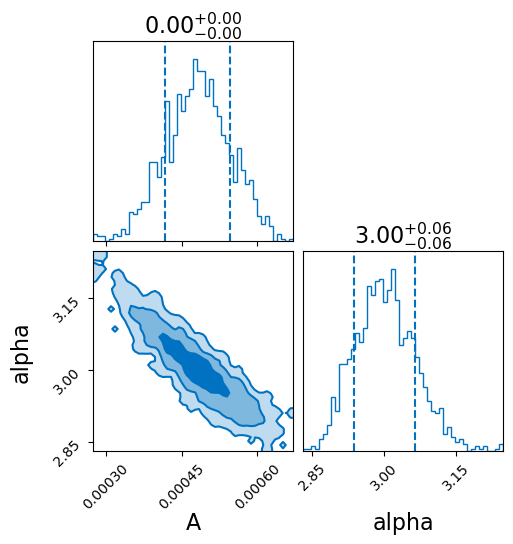

In [9]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],var_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=50000)
result.plot_corner()

In [10]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

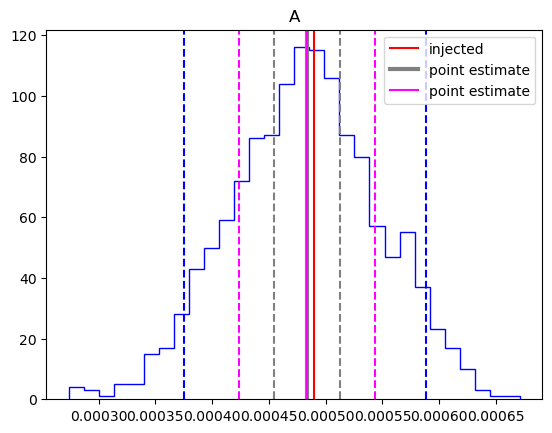

In [11]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red', label='injected')


plt.axvline(Y_opt,color='grey', linewidth=3, label='point estimate')
plt.axvline(Y_opt+sig_opt_alt,color='grey', linestyle='--')
plt.axvline(Y_opt-sig_opt_alt,color='grey', linestyle='--')

plt.axvline(Y_opt,color='magenta', linestyle='-', label='point estimate')
plt.axvline(Y_opt+sig_opt,color='magenta', linestyle='--')
plt.axvline(Y_opt-sig_opt,color='magenta', linestyle='--')

plt.legend()

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

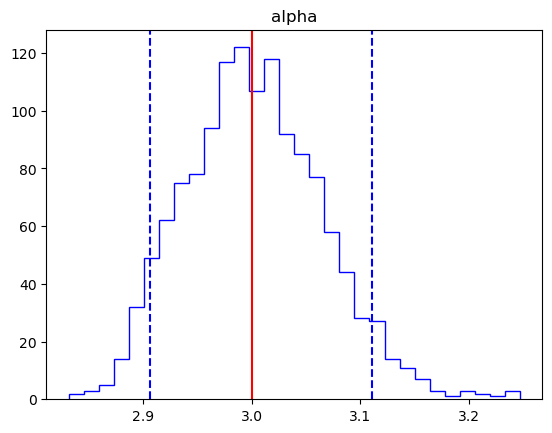

In [12]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')